In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib

Using matplotlib backend: <object object at 0x7c0c0cff70c0>


In [2]:
from google.colab import files
uploaded=files.upload()

Saving WineDataset.csv to WineDataset.csv


In [3]:
df=pd.read_csv('/content/WineDataset.csv')
df.head()

,Title,Description,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Unit,Characteristics,Per bottle / case / each,Type,ABV,Region,Style,Vintage,Appellation
0,"The Guv'nor, Spain",We asked some of our most prized winemakers wo...,£9.99 per bottle,75CL,Tempranillo,NaN,Natural Cork,Spain,10.5,"Vanilla, Blackberry, Blackcurrant",per bottle,Red,ABV 14.00%,NaN,Rich & Juicy,NV,NaN
1,Bread & Butter 'Winemaker's Selection' Chardon...,This really does what it says on the tin. It’s...,£15.99 per bottle,75CL,Chardonnay,NaN,Natural Cork,USA,10.1,"Vanilla, Almond, Coconut, Green Apple, Peach, ...",per bottle,White,ABV 13.50%,California,Rich & Toasty,2021,Napa Valley
2,"Oyster Bay Sauvignon Blanc 2022, Marlborough",Oyster Bay has been an award-winning gold-stan...,£12.49 per bottle,75CL,Sauvignon Blanc,NaN,Screwcap,New Zealand,9.8,"Tropical Fruit, Gooseberry, Grapefruit, Grass,...",per bottle,White,ABV 13.00%,Marlborough,Crisp & Zesty,2022,NaN
3,Louis Latour Mâcon-Lugny 2021/22,We’ve sold this wine for thirty years – and fo...,£17.99 per bottle,75CL,Chardonnay,NaN,Natural Cork,France,10.1,"Peach, Apricot, Floral, Lemon",per bottle,White,ABV 13.50%,Burgundy,Ripe & Rounded,2022,Macon
4,Bread & Butter 'Winemaker's Selection' Pinot N...,Bread & Butter is that thing that you can coun...,£15.99 per bottle,75CL,Pinot Noir,NaN,Natural Cork,USA,10.1,"Smoke, Black Cherry, Cedar, Raspberry, Red Fruit",per bottle,Red,ABV 13.50%,California,Smooth & Mellow,2021,Napa Valley


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290 entries, 0 to 1289
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      1290 non-null   object 
 1   Description                1286 non-null   object 
 2   Price                      1290 non-null   object 
 3   Capacity                   1290 non-null   object 
 4   Grape                      1275 non-null   object 
 5   Secondary Grape Varieties  488 non-null    object 
 6   Closure                    1279 non-null   object 
 7   Country                    1284 non-null   object 
 8   Unit                       1281 non-null   float64
 9   Characteristics            1253 non-null   object 
 10  Per bottle / case / each   1290 non-null   object 
 11  Type                       1285 non-null   object 
 12  ABV                        1281 non-null   object 
 13  Region                     1124 non-null   objec

In [5]:
df.describe()

,Unit
count,1281.000000
mean,10.177674
std,2.318850
min,0.000000
25%,9.400000
50%,10.100000
75%,10.500000
max,39.000000


In [6]:
df.isnull().sum()

,0
Title,0
Description,4
Price,0
Capacity,0
Grape,15
Secondary Grape Varieties,802
Closure,11
Country,6
Unit,9
Characteristics,37


In [7]:
df.drop(columns=[
    'Title',
    'Description',
    'Secondary Grape Varieties',
    'Appellation'
], inplace=True)

In [8]:
df.isnull().sum()

,0
Price,0
Capacity,0
Grape,15
Closure,11
Country,6
Unit,9
Characteristics,37
Per bottle / case / each,0
Type,5
ABV,9


In [10]:

df['Unit'] = df['Unit'].fillna(df['Unit'].median())


cols = [
    'Grape',
    'Closure',
    'Country',
    'Characteristics',
    'Type',
    'ABV',
    'Region',
    'Style',
    'Vintage'
]

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.isnull().sum()

,0
Price,0
Capacity,0
Grape,0
Closure,0
Country,0
Unit,0
Characteristics,0
Per bottle / case / each,0
Type,0
ABV,0


In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Type', data=df)
plt.title("Distribution of Wine Types")
plt.xticks(rotation=45)
plt.show()

In [15]:
df['Unit'] = pd.to_numeric(df['Unit'], errors='coerce')

In [17]:
print(df['Unit'].describe())

count    1290.000000
mean       10.177132
std         2.310749
min         0.000000
25%         9.400000
50%        10.100000
75%        10.500000
max        39.000000
Name: Unit, dtype: float64


In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Unit'])

plt.title("Boxplot of Unit")

plt.show()

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

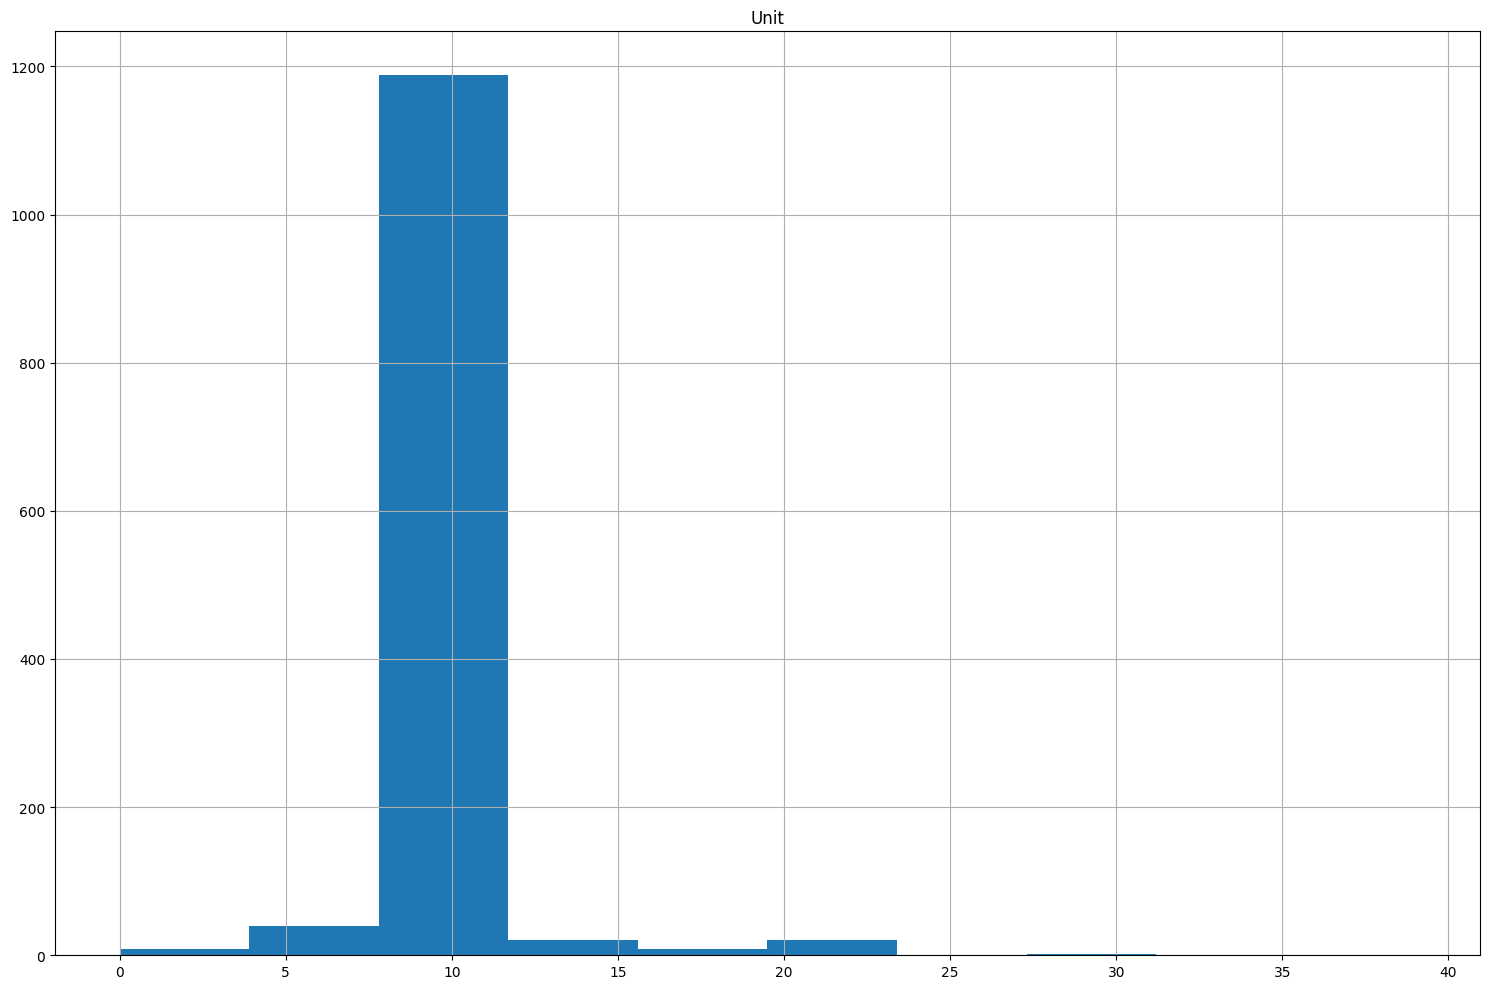

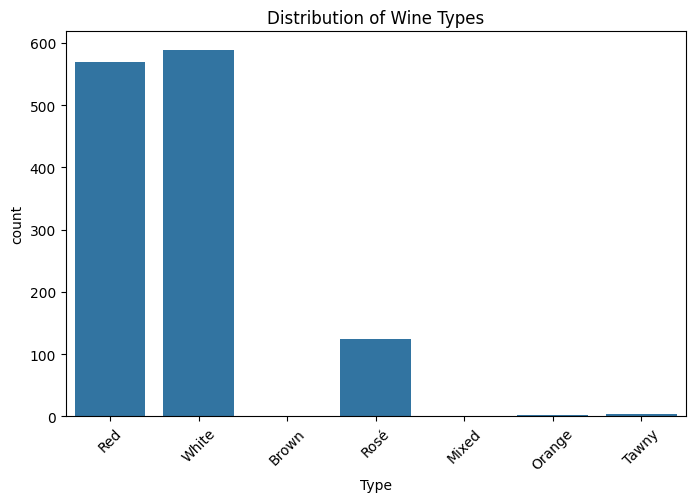

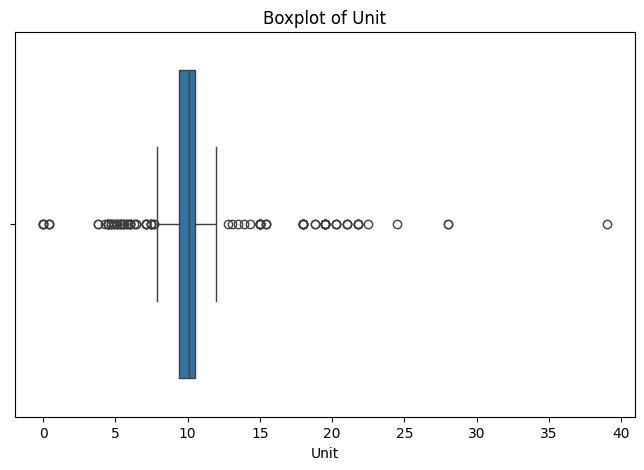

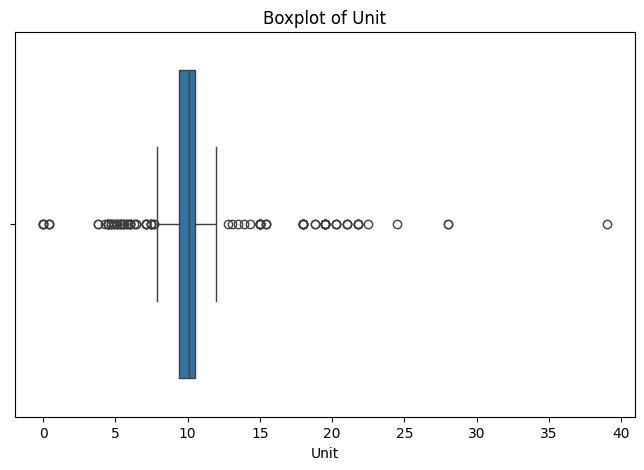

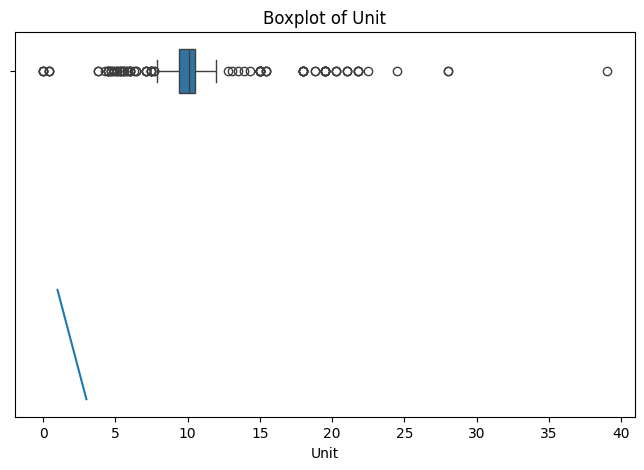

In [20]:
plt.plot([1,2,3],[4,5,6])
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df['Price'] = df['Price'].str.replace('£', '').str.replace('per bottle', '').str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


df['Capacity'] = df['Capacity'].str.replace('CL', '').str.strip()
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')


df['ABV'] = df['ABV'].str.replace('ABV ', '').str.replace('%', '').str.strip()
df['ABV'] = pd.to_numeric(df['ABV'], errors='coerce')


df['Price'] = df['Price'].fillna(df['Price'].median())
df['Capacity'] = df['Capacity'].fillna(df['Capacity'].median())
df['ABV'] = df['ABV'].fillna(df['ABV'].median())

y = df['Type']


features = [
    'Price', 'Capacity', 'Grape', 'Closure', 'Country', 'Unit',
    'Characteristics', 'Per bottle / case / each', 'ABV', 'Region', 'Style', 'Vintage'
]
X = df[features]


X = pd.get_dummies(X, columns=['Grape', 'Closure', 'Country', 'Characteristics',
                               'Per bottle / case / each', 'Region', 'Style', 'Vintage'], drop_first=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)



X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9186046511627907


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])

[[-2.38168227 -1.23302808]
 [-1.35005985  0.18821343]
 [ 5.80101587  1.5025997 ]
 [-0.88336102  2.16985155]
 [-0.46412987 -1.10856222]]


In [24]:
principal_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

principal_df.head()

,PC1,PC2
0,-2.381682,-1.233028
1,-1.350060,0.188213
2,5.801016,1.502600
3,-0.883361,2.169852
4,-0.464130,-1.108562


In [25]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.00432427 0.00407659]

Total Explained Variance:
0.008400861026258378


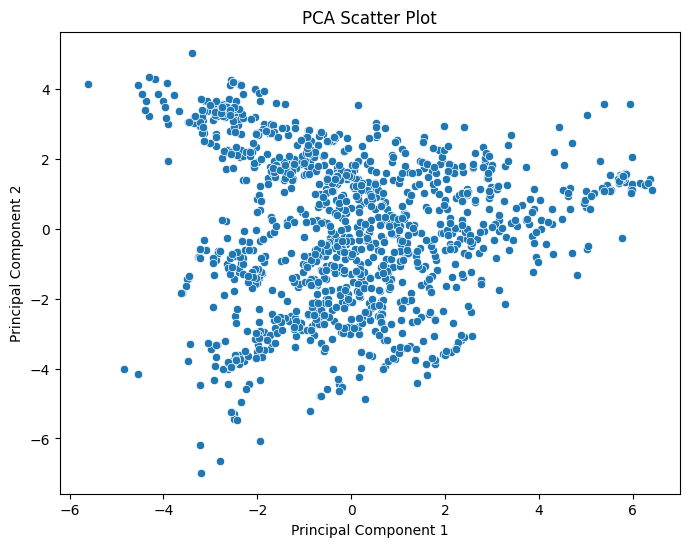

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=principal_df["PC1"],
    y=principal_df["PC2"]
)

plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [28]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

loadings

,Price,Capacity,Unit,ABV,Grape_Aglianico,Grape_Airen,Grape_Albarino,Grape_Alicante Bouschet,Grape_Aligoté,Grape_Alvarinho,...,Vintage_2020,Vintage_2020/2021,Vintage_2020/2022,Vintage_2020/21,Vintage_2021,Vintage_2021/2022,Vintage_2021/22,Vintage_2022,Vintage_2023,Vintage_NV
PC1,-0.184187,-0.005057,-0.05596,-0.080497,-0.006549,-0.016635,0.055522,-0.002121,-0.003295,0.031400,...,-0.008823,-0.017342,-0.011167,-0.001889,0.071361,-0.013688,0.000604,0.206253,0.075976,-0.174391
PC2,0.092303,0.005830,-0.12352,-0.227340,-0.019697,0.010891,0.007909,-0.036069,0.015783,-0.010351,...,-0.065968,0.017108,0.015993,-0.003201,-0.021486,0.023091,-0.006123,0.087108,0.002418,0.158175


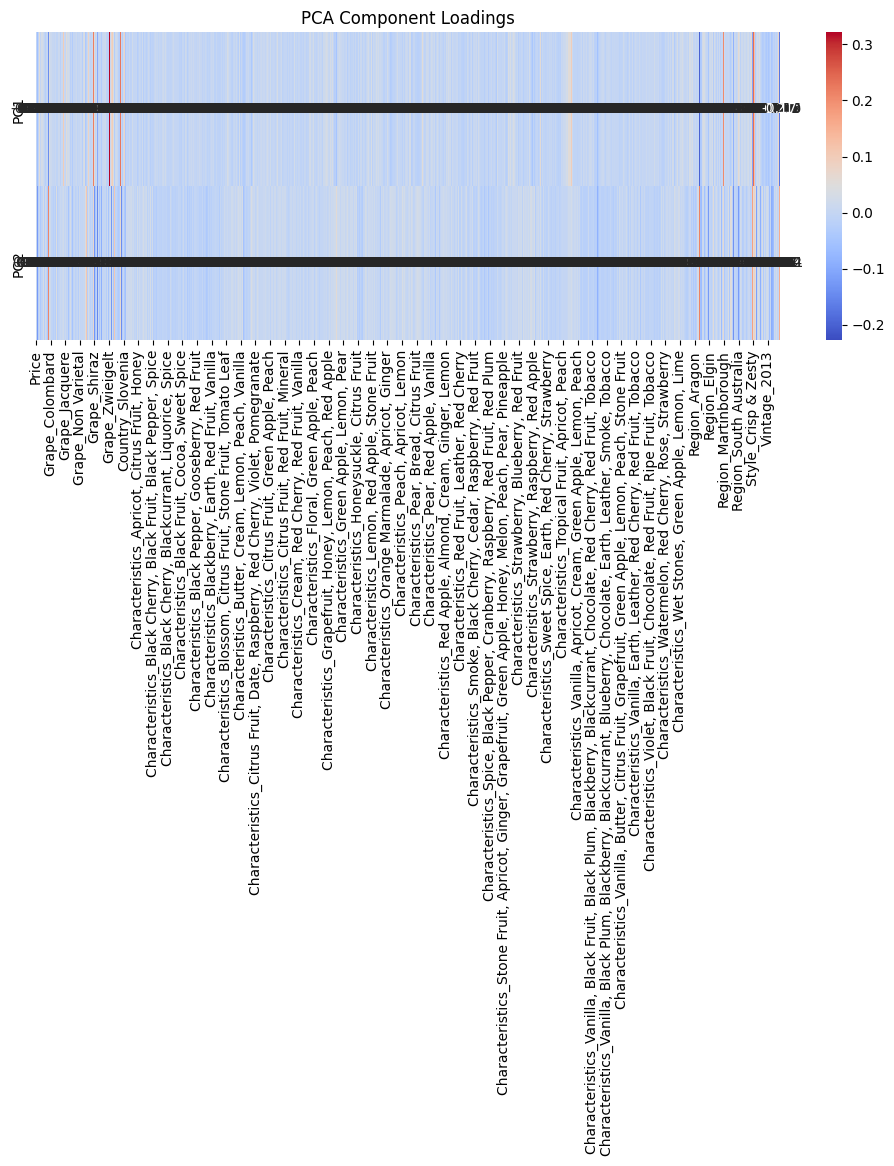

In [30]:
plt.figure(figsize=(12,4))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm"
)

plt.title("PCA Component Loadings")

plt.show()

In [31]:
principal_df.to_csv("PCA_Output.csv", index=False)

print("PCA output saved successfully.")

PCA output saved successfully.


In [32]:
print("PCA was successfully applied to the dataset.")
print("The dataset was standardized before PCA.")
print("The dimensionality of the dataset was reduced.")
print("The first two principal components retained most of the important information.")
print("PCA helps reduce complexity while preserving maximum variance.")

PCA was successfully applied to the dataset.
The dataset was standardized before PCA.
The dimensionality of the dataset was reduced.
The first two principal components retained most of the important information.
PCA helps reduce complexity while preserving maximum variance.
